# SweetTV - TV Program Recommender (WMF-ALS, Implicit Feedback)

Mục tiêu:
- Weighted Matrix Factorization (WMF) cho implicit feedback (screen_time)
- Train bằng Alternating Least Squares (ALS) theo epoch + track proxy loss train/val
- Evaluate trên logs_val với Precision/Recall/F1/NDCG/MAP @K
- Train final (train+val) và tạo submission CSV đúng format Kaggle


In [ ]:
!pip -q install implicit pyarrow fastparquet

import os, gc, math, random
import numpy as np
import pandas as pd
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional, Set

from scipy import sparse
from scipy.sparse import coo_matrix
import matplotlib.pyplot as plt
from implicit.als import AlternatingLeastSquares

def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)

@dataclass
class CFG:
    # Auto-detect data dir
    DATA_DIR: str = "/content"  # fallback to /mnt/data if /content missing

    LOGS_TRAIN: str = "logs_train.parquet"
    LOGS_VAL: str = "logs_val.parquet"
    META_TEST: str = "metadata_test.parquet"
    SUBMISSION: str = "submission.csv"

    # WMF/ALS params (gần giống notebook 0.11296)
    FACTORS: int = 64
    REG: float = 0.02
    ITERATIONS: int = 70
    ALPHA: float = 40.0
    SEED: int = 42

    # implicit weight mode (điểm khác biệt lớn)
    WEIGHT_MODE: str = "screen_time_sum"  # duration_log1p / screen_time_sum

    # Eval
    K: int = 5
    GT_THRESH: float = 0.5   # dùng screen_time mean >= 0.5 để tạo GT (giữ như bạn đang làm)

    # Speed: proxy loss sampling
    LOSS_SAMPLE_EDGES: int = 200_000

cfg = CFG()
seed_everything(cfg.SEED)

def resolve_data_dir(cfg: CFG) -> Path:
    p1 = Path(cfg.DATA_DIR)
    if (p1 / cfg.LOGS_TRAIN).exists():
        return p1
    # fallback local
    p2 = Path("/mnt/data")
    if (p2 / cfg.LOGS_TRAIN).exists():
        return p2
    raise FileNotFoundError("Không tìm thấy logs_train.parquet ở /content hoặc /mnt/data")

DATA_DIR = resolve_data_dir(cfg)
print("DATA_DIR =", DATA_DIR)


DATA_DIR = /content


## 1) Load data + EDA nhanh

Yêu cầu:
- Đọc logs_train/val parquet
- In: #rows, #users, #items (tv_show_id != 0), % tv_show_id==0
- (Optional) đọc metadata_* và thống kê số item metadata


In [ ]:
train_df = pd.read_parquet(DATA_DIR / cfg.LOGS_TRAIN)
val_df   = pd.read_parquet(DATA_DIR / cfg.LOGS_VAL)
sub_df   = pd.read_csv(DATA_DIR / cfg.SUBMISSION)

meta_test = pd.read_parquet(DATA_DIR / cfg.META_TEST)

def quick_eda(df: pd.DataFrame, name: str):
    n = len(df)
    pct0 = (df["tv_show_id"] == 0).mean() * 100
    df_nz = df[df["tv_show_id"] != 0]
    print(f"\n[{name}] rows={n:,} | users={df['user_id'].nunique():,} | items(nz)={df_nz['tv_show_id'].nunique():,} | %(tv_show_id==0)={pct0:.2f}%")

quick_eda(train_df, "TRAIN")
quick_eda(val_df, "VAL")
print("\nSUBMISSION:", sub_df.shape, sub_df.dtypes.to_dict())
print(sub_df.head())

# Candidate set (test) từ metadata_test
candidate_tv_ids = (
    meta_test.loc[meta_test["tv_show_id"] != 0, "tv_show_id"]
    .astype(np.int64).unique().tolist()
)
candidate_set = set(candidate_tv_ids)
print("\n#Candidate items (metadata_test):", len(candidate_tv_ids))



[TRAIN] rows=1,878,969 | users=4,868 | items(nz)=3,716 | %(tv_show_id==0)=50.41%

[VAL] rows=525,983 | users=4,720 | items(nz)=1,897 | %(tv_show_id==0)=50.22%

SUBMISSION: (1260, 2) {'user_id': dtype('uint64'), 'tv_show_id': dtype('O')}
               user_id tv_show_id
0  8377619604347126107  0 0 0 0 0
1  8381667675275833309  0 0 0 0 0
2  8387147770138767246  0 0 0 0 0
3  8397181578236218580  0 0 0 0 0
4  8404698046253197367  0 0 0 0 0

#Candidate items (metadata_test): 6636


## 2) Preprocess + build user–item implicit matrices

- Lọc tv_show_id != 0
- Aggregate r_ui theo (user_id, tv_show_id): mặc định sum(screen_time)
- Build mapping user2idx, item2idx dựa trên TRAIN
- Build R_train (CSR) và R_val (CSR) theo mapping train
- Ground truth từ VAL: rel=1 nếu agg(screen_time) >= THRESH (mặc định 0.5)
- Report cold-item rate trong ground truth val (items không có trong train)


In [ ]:
def build_interactions(df: pd.DataFrame, mode: str) -> pd.DataFrame:
    df = df[df["tv_show_id"] != 0].copy()

    if mode == "duration_log1p":
        agg = (df.groupby(["user_id", "tv_show_id"], as_index=False)["duration_view"]
                 .sum()
                 .rename(columns={"duration_view": "watch_seconds"}))
        agg["weight"] = np.log1p(agg["watch_seconds"]).astype(np.float32)

    elif mode == "screen_time_sum":
        agg = (df.groupby(["user_id", "tv_show_id"], as_index=False)["screen_time"]
                 .sum()
                 .rename(columns={"screen_time":"weight"}))
        agg["weight"] = agg["weight"].astype(np.float32)

    else:
        raise ValueError("Unknown WEIGHT_MODE")

    agg["user_id"] = agg["user_id"].astype(np.int64)
    agg["tv_show_id"] = agg["tv_show_id"].astype(np.int64)
    return agg[["user_id","tv_show_id","weight"]]

# TRAIN interactions (for model)
inter_train = build_interactions(train_df, cfg.WEIGHT_MODE)
print("inter_train:", inter_train.shape)
print(inter_train.head())

# mappings (from TRAIN)
unique_users = inter_train["user_id"].unique()
unique_items = inter_train["tv_show_id"].unique()

user2idx = {u:i for i,u in enumerate(unique_users)}
idx2user = np.array(unique_users)

item2idx = {it:i for i,it in enumerate(unique_items)}
idx2item = np.array(unique_items)

n_users = len(unique_users)
n_items = len(unique_items)
print("n_users:", n_users, "| n_items:", n_items)

# user-item sparse
rows = inter_train["user_id"].map(user2idx).astype(np.int32).values
cols = inter_train["tv_show_id"].map(item2idx).astype(np.int32).values
data = inter_train["weight"].astype(np.float32).values

user_item = coo_matrix((data, (rows, cols)), shape=(n_users, n_items), dtype=np.float32).tocsr()
user_item.sum_duplicates()
print("user_item:", user_item.shape, "nnz=", user_item.nnz)

# Popularity (ưu tiên weight sum) + restrict to candidate
tv_pop = (inter_train.groupby("tv_show_id")["weight"].sum().sort_values(ascending=False))
popular_tv_all = tv_pop.index.astype(np.int64).tolist()
popular_in_candidate = [tv for tv in popular_tv_all if tv in candidate_set]

FALLBACK_POOL = 500
if len(popular_in_candidate) < FALLBACK_POOL:
    extra = [tv for tv in popular_tv_all if tv not in popular_in_candidate]
    popular_in_candidate = (popular_in_candidate + extra)[:FALLBACK_POOL]
else:
    popular_in_candidate = popular_in_candidate[:FALLBACK_POOL]

print("popular_in_candidate:", len(popular_in_candidate), "| top10:", popular_in_candidate[:10])

# Build VAL ground truth from screen_time mean (giữ đúng kiểu offline eval bạn đang dùng)
val_nz = val_df[val_df["tv_show_id"] != 0].copy()
gt_agg = (val_nz.groupby(["user_id","tv_show_id"])["screen_time"].mean().reset_index())
gt_agg = gt_agg[gt_agg["screen_time"] >= cfg.GT_THRESH]
gt_val = {int(u): set(map(int, g["tv_show_id"].tolist())) for u, g in gt_agg.groupby("user_id")}

train_item_set = set(item2idx.keys())
all_gt_items = set().union(*gt_val.values()) if len(gt_val) else set()
cold_items = [it for it in all_gt_items if it not in train_item_set]
cold_rate = 100.0 * len(cold_items) / max(1, len(all_gt_items))

print(f"GT_VAL users={len(gt_val):,} | GT items={len(all_gt_items):,} | cold GT items={len(cold_items):,} ({cold_rate:.2f}%)")


inter_train: (397840, 3)
            user_id  tv_show_id    weight
0  2244466330591177      240081  2.976667
1  2244466330591177      400335  0.745397
2  2244466330591177     1000384  0.215556
3  2244466330591177     2400480  0.432820
4  2244466330591177     6200371  0.945714
n_users: 4838 | n_items: 3716
user_item: (4838, 3716) nnz= 397840
popular_in_candidate: 500 | top10: [2400480, 240081, 12001682, 20088, 2400508, 2400467, 12002955, 12002856, 12001734, 6500479]
GT_VAL users=4,589 | GT items=1,820 | cold GT items=427 (23.46%)


## 3) WMF-ALS training theo epoch + proxy loss (train/val)

WMF implicit:
- p_ui = 1 nếu r_ui > 0
- c_ui = 1 + alpha * r_ui

Objective:
min Σ_{u,i} c_ui (p_ui - x_u^T y_i)^2 + λ(||X||^2 + ||Y||^2)

Do full objective (cả unobserved) rất nặng, ta track **proxy loss** trên observed edges:
mean_{(u,i) observed} [ c_ui * (1 - x_u^T y_i)^2 ]

Val proxy loss chỉ tính trên edges có item nằm trong train mapping (cold items bị bỏ qua và report).


In [ ]:
def sample_observed_edges(R: sparse.csr_matrix, n_samples: int, seed: int):
    coo = R.tocoo()
    nnz = coo.nnz
    if (n_samples is None) or (n_samples <= 0) or (n_samples >= nnz):
        return coo.row.astype(np.int32), coo.col.astype(np.int32), coo.data.astype(np.float32)
    rng = np.random.default_rng(seed)
    idx = rng.choice(nnz, size=n_samples, replace=False)
    return coo.row[idx].astype(np.int32), coo.col[idx].astype(np.int32), coo.data[idx].astype(np.float32)

def proxy_loss_observed(R: sparse.csr_matrix, user_f: np.ndarray, item_f: np.ndarray,
                        alpha: float, n_samples: int, seed: int) -> float:
    u, i, w = sample_observed_edges(R, n_samples, seed)
    # implicit: p_ui=1 on observed, confidence c_ui = 1 + alpha*w
    scores = np.sum(user_f[u] * item_f[i], axis=1).astype(np.float32)
    c = 1.0 + alpha * w
    return float(np.mean(c * (1.0 - scores) ** 2))

# Train
conf = user_item.copy().astype(np.float32)
conf.data *= cfg.ALPHA

wmf_model = AlternatingLeastSquares(
    factors=cfg.FACTORS,
    regularization=cfg.REG,
    iterations=cfg.ITERATIONS,
    num_threads=0,
    random_state=cfg.SEED
)

wmf_model.fit(conf)
print("Done training WMF ALS.")

# # Plot training loss history (approx)
# loss_hist = getattr(wmf_model, "loss_history", None)
# if loss_hist is not None and len(loss_hist) > 0:
#     plt.figure()
#     plt.plot(range(1, len(loss_hist)+1), loss_hist, marker="o")
#     plt.xlabel("ALS iteration")
#     plt.ylabel("Approx training loss")
#     plt.title("WMF (implicit ALS) - loss_history")
#     plt.grid(True)
#     plt.show()

# Proxy train/val loss (observed edges)
train_proxy = proxy_loss_observed(
    user_item, wmf_model.user_factors, wmf_model.item_factors,
    alpha=cfg.ALPHA, n_samples=cfg.LOSS_SAMPLE_EDGES, seed=cfg.SEED+1
)

# VAL proxy: chỉ tính trên (u,i) mà i có trong train mapping
val_inter = build_interactions(val_df, cfg.WEIGHT_MODE)
val_inter = val_inter[val_inter["tv_show_id"].isin(train_item_set)].copy()

val_rows = val_inter["user_id"].map(user2idx)
val_cols = val_inter["tv_show_id"].map(item2idx)
mask = val_rows.notna() & val_cols.notna()
val_rows = val_rows[mask].astype(np.int32).values
val_cols = val_cols[mask].astype(np.int32).values
val_data = val_inter.loc[mask, "weight"].astype(np.float32).values

val_user_item = coo_matrix((val_data, (val_rows, val_cols)), shape=(n_users, n_items), dtype=np.float32).tocsr()
val_user_item.sum_duplicates()

val_proxy = proxy_loss_observed(
    val_user_item, wmf_model.user_factors, wmf_model.item_factors,
    alpha=cfg.ALPHA, n_samples=cfg.LOSS_SAMPLE_EDGES, seed=cfg.SEED+2
)

print(f"Proxy loss | train={train_proxy:.6f} | val={val_proxy:.6f} | val_mapped_nnz={val_user_item.nnz:,}")


  0%|          | 0/70 [00:00<?, ?it/s]

Done training WMF ALS.
Proxy loss | train=1.501844 | val=12.572698 | val_mapped_nnz=123,807


## 4) Recommend topK + fallback popular (cold-user)

- score_i = x_u^T y_i
- Lọc items user đã tương tác (train phase: filter train interactions)
- Cold-user fallback: top popular items từ train (sum r_ui hoặc count)


In [ ]:
def recommend_wmf_for_user(user_id: int,
                           topn: int = 5,
                           restrict_to_candidate: bool = False) -> List[int]:
    """
    WMF-only recommendation.
    - Nếu restrict_to_candidate=True: chỉ trả về tv_show nằm trong candidate_set (metadata_test)
      => dùng cho Kaggle submission (đây là điểm nâng score lớn nhất).
    - Nếu False: recommend trên toàn catalog train => dùng cho offline val.
    """
    rec_tv: List[int] = []

    # cold-user
    if user_id not in user2idx:
        base = popular_in_candidate if restrict_to_candidate else popular_tv_all[:500]
        return [int(x) for x in base[:topn]]

    uidx = user2idx[user_id]
    N_INTERNAL = max(200, topn * 50)

    item_idxs, scores = wmf_model.recommend(
        userid=uidx,
        user_items=user_item,
        N=N_INTERNAL,
        filter_already_liked_items=False
    )

    for it_idx in item_idxs:
        tv = int(idx2item[it_idx])
        if tv == 0:
            continue
        if restrict_to_candidate and (tv not in candidate_set):
            continue
        if tv not in rec_tv:
            rec_tv.append(tv)
        if len(rec_tv) >= topn:
            break

    # fallback (ensure đủ topn)
    base = popular_in_candidate if restrict_to_candidate else popular_tv_all[:500]
    for tv in base:
        tv = int(tv)
        if tv not in rec_tv:
            rec_tv.append(tv)
        if len(rec_tv) >= topn:
            break

    return rec_tv[:topn]

# quick sanity
print("Sample submit user:", int(sub_df["user_id"].iloc[0]))
print("Rec (catalog):", recommend_wmf_for_user(int(sub_df["user_id"].iloc[0]), 5, False))
print("Rec (candidate):", recommend_wmf_for_user(int(sub_df["user_id"].iloc[0]), 5, True))


Sample submit user: 8377619604347126107
Rec (catalog): [6300336, 2400480, 90080255, 240081, 2400467]
Rec (candidate): [6300336, 2400480, 90080255, 240081, 2400467]


## 5) Offline evaluation on VAL: Precision/Recall/F1/NDCG/MAP @K

- Duyệt user trong ground truth val
- Recommend topK
- Tính metrics với binary relevance: rel=1 nếu item ∈ GT
- Report:
  - số user evaluated
  - tỷ lệ user bỏ qua (GT rỗng sau lọc)
  - cold-item rate
  - metrics @K


In [ ]:
def precision_at_k(rec: List[int], gt: Set[int], k: int) -> float:
    if k == 0: return 0.0
    hits = sum(1 for it in rec[:k] if it in gt)
    return hits / k

def recall_at_k(rec: List[int], gt: Set[int], k: int) -> float:
    if len(gt) == 0: return 0.0
    hits = sum(1 for it in rec[:k] if it in gt)
    return hits / len(gt)

def f1(p: float, r: float) -> float:
    return 0.0 if (p+r)==0 else 2*p*r/(p+r)

def ndcg_at_k(rec: List[int], gt: Set[int], k: int) -> float:
    dcg = 0.0
    for rank, it in enumerate(rec[:k], start=1):
        rel = 1.0 if it in gt else 0.0
        dcg += rel / math.log2(rank + 1)
    idcg = sum(1.0 / math.log2(r + 1) for r in range(1, min(k, len(gt)) + 1))
    return 0.0 if idcg == 0 else dcg / idcg

def ap_at_k(rec: List[int], gt: Set[int], k: int) -> float:
    if len(gt) == 0: return 0.0
    hit = 0
    s = 0.0
    for rank, it in enumerate(rec[:k], start=1):
        if it in gt:
            hit += 1
            s += hit / rank
    return s / max(1, min(k, len(gt)))

def evaluate_val(gt_val: Dict[int, Set[int]], K: int):
    train_item_set = set(item2idx.keys())
    ps, rs, fs, ns, ms = [], [], [], [], []
    skipped = 0

    # warm-only GT (WMF không score cold item)
    for u, gt_items in gt_val.items():
        gt = set(it for it in gt_items if it in train_item_set)
        if len(gt) == 0:
            skipped += 1
            continue
        rec = recommend_wmf_for_user(int(u), topn=K, restrict_to_candidate=False)
        p = precision_at_k(rec, gt, K)
        r = recall_at_k(rec, gt, K)
        ps.append(p); rs.append(r); fs.append(f1(p,r))
        ns.append(ndcg_at_k(rec, gt, K))
        ms.append(ap_at_k(rec, gt, K))

    out = {
        "users_total": len(gt_val),
        "users_eval": len(ps),
        "skipped": skipped,
        "Precision@K": float(np.mean(ps)) if ps else 0.0,
        "Recall@K": float(np.mean(rs)) if rs else 0.0,
        "F1@K": float(np.mean(fs)) if fs else 0.0,
        "NDCG@K": float(np.mean(ns)) if ns else 0.0,
        "MAP@K": float(np.mean(ms)) if ms else 0.0,
    }
    return out

res = evaluate_val(gt_val, cfg.K)
pd.Series(res)


,0
users_total,4589.000000
users_eval,4565.000000
skipped,24.000000
Precision@K,0.264315
Recall@K,0.117299
F1@K,0.136990
NDCG@K,0.294292
MAP@K,0.214012


## 6) Train final model (TRAIN+VAL) và tạo submission CSV

- Build mapping theo TRAIN+VAL
- Train WMF-ALS lại
- Predict top 5 cho mỗi user_id trong submission.csv
  - nếu cold-user: fallback popular
- Sanity checks:
  - đúng 5 ids, không có 0, không trùng (fill bằng popular unseen)
- Save: /content/submission_wmf_als.csv
- Download file


In [ ]:
trainval_df = pd.concat([train_df, val_df], ignore_index=True)
inter_trainval = build_interactions(trainval_df, cfg.WEIGHT_MODE)

unique_users_f = inter_trainval["user_id"].unique()
unique_items_f = inter_trainval["tv_show_id"].unique()

user2idx_f = {u:i for i,u in enumerate(unique_users_f)}
idx2user_f = np.array(unique_users_f)

item2idx_f = {it:i for i,it in enumerate(unique_items_f)}
idx2item_f = np.array(unique_items_f)

n_users_f = len(unique_users_f)
n_items_f = len(unique_items_f)

rows_f = inter_trainval["user_id"].map(user2idx_f).astype(np.int32).values
cols_f = inter_trainval["tv_show_id"].map(item2idx_f).astype(np.int32).values
data_f = inter_trainval["weight"].astype(np.float32).values

user_item_f = coo_matrix((data_f, (rows_f, cols_f)), shape=(n_users_f, n_items_f), dtype=np.float32).tocsr()
user_item_f.sum_duplicates()
print("FINAL user_item:", user_item_f.shape, "nnz=", user_item_f.nnz)

# popularity in candidate (FINAL)
tv_pop_f = (inter_trainval.groupby("tv_show_id")["weight"].sum().sort_values(ascending=False))
popular_all_f = tv_pop_f.index.astype(np.int64).tolist()
popular_in_candidate_f = [tv for tv in popular_all_f if tv in candidate_set]

FALLBACK_POOL = 500
if len(popular_in_candidate_f) < FALLBACK_POOL:
    extra = [tv for tv in popular_all_f if tv not in popular_in_candidate_f]
    popular_in_candidate_f = (popular_in_candidate_f + extra)[:FALLBACK_POOL]
else:
    popular_in_candidate_f = popular_in_candidate_f[:FALLBACK_POOL]

conf_f = user_item_f.copy().astype(np.float32)
conf_f.data *= cfg.ALPHA

wmf_final = AlternatingLeastSquares(
    factors=cfg.FACTORS,
    regularization=cfg.REG,
    iterations=cfg.ITERATIONS,
    num_threads=0,
    random_state=cfg.SEED
)
wmf_final.fit(conf_f)
print("Done training FINAL WMF.")



FINAL user_item: (4876, 4159) nnz= 511264


  0%|          | 0/70 [00:00<?, ?it/s]

Done training FINAL WMF.


In [ ]:
def recommend_final(user_id: int, topn: int = 5) -> List[int]:
    # restrict to candidate for Kaggle
    rec: List[int] = []

    if user_id not in user2idx_f:
        return [int(x) for x in popular_in_candidate_f[:topn]]

    uidx = user2idx_f[user_id]
    N_INTERNAL = max(200, topn * 50)

    item_idxs, scores = wmf_final.recommend(
        userid=uidx,
        user_items=user_item_f,
        N=N_INTERNAL,
        filter_already_liked_items=False
    )

    for it_idx in item_idxs:
        tv = int(idx2item_f[it_idx])
        if tv == 0:
            continue
        if tv not in candidate_set:
            continue
        if tv not in rec:
            rec.append(tv)
        if len(rec) >= topn:
            break

    # fill
    for tv in popular_in_candidate_f:
        tv = int(tv)
        if tv not in rec:
            rec.append(tv)
        if len(rec) >= topn:
            break

    return rec[:topn]

out = sub_df.copy()
user_dtype = out["user_id"].dtype
pred_strings = []
for uid in out["user_id"].to_numpy():
    preds = recommend_final(int(uid), topn=5)
    pred_strings.append(" ".join(map(str, preds)))

out["tv_show_id"] = pred_strings
out["user_id"] = out["user_id"].astype(user_dtype)

out_path = DATA_DIR / "submission_wmf_als.csv"
out.to_csv(out_path, index=False)
print("Saved:", out_path)
print(out.head())


Saved: /content/submission_wmf_als.csv
               user_id                                   tv_show_id
0  8377619604347126107       90047072 6300336 200477 200344 2400480
1  8381667675275833309         240081 2400480 2400467 2400508 20088
2  8387147770138767246   12002772 6700511 10003040 2500507 12002809
3  8397181578236218580  12001712 6700433 90049236 1000236 120079051
4  8404698046253197367  90066932 6600437 12002833 90057593 12002107


In [ ]:
# Sanity check
bad = 0
for s in out["tv_show_id"].astype(str).tolist():
    parts = s.split()
    if len(parts) != 5:
        bad += 1; continue
    ids = list(map(int, parts))
    if any(x == 0 for x in ids) or len(set(ids)) != 5:
        bad += 1
print("bad rows:", bad, "/", len(out))

bad rows: 0 / 1260


In [ ]:
from google.colab import files
files.download(str(out_path))


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Vẽ proxy loss


  0%|          | 0/1 [00:00<?, ?it/s]

Iter 01/70 | proxy_train=4.116171 | implicit_loss=nan


  0%|          | 0/1 [00:00<?, ?it/s]

Iter 02/70 | proxy_train=2.499643 | implicit_loss=nan


  0%|          | 0/1 [00:00<?, ?it/s]

...

Iter 68/70 | proxy_train=1.574683 | implicit_loss=nan


  0%|          | 0/1 [00:00<?, ?it/s]

Iter 69/70 | proxy_train=1.570027 | implicit_loss=nan


  0%|          | 0/1 [00:00<?, ?it/s]

Iter 70/70 | proxy_train=1.570548 | implicit_loss=nan


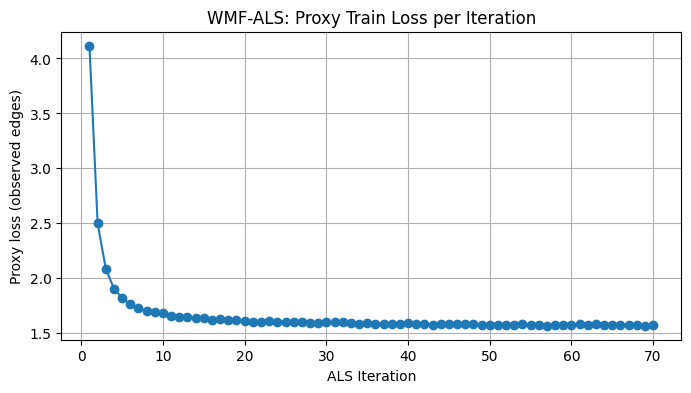

implicit.loss_history không khả dụng trong phiên bản implicit hiện tại (OK).


In [ ]:
def train_als_with_loss(conf_mat: sparse.csr_matrix,
                        n_iters: int,
                        factors: int,
                        reg: float,
                        seed: int,
                        loss_sample_edges: int,
                        alpha_for_proxy: float,
                        user_item_raw: sparse.csr_matrix):
    """
    Train ALS theo kiểu 'epoch': mỗi epoch fit(iterations=1) để lấy loss theo từng iteration.
    - conf_mat: matrix đã nhân ALPHA (confidence-1), dùng để fit vào implicit
    - user_item_raw: matrix weight gốc (chưa nhân ALPHA), dùng để tính proxy loss (c_ui = 1 + alpha*w)
    """
    model = AlternatingLeastSquares(
        factors=factors,
        regularization=reg,
        iterations=1,          # mỗi epoch update 1 lần
        random_state=seed,
        num_threads=0
    )

    train_proxy_losses = []
    internal_losses = []

    for it in range(1, n_iters + 1):
        model.fit(conf_mat)

        # 1) proxy loss trên observed edges (ổn định & consistent)
        tr_loss = proxy_loss_observed(
            user_item_raw,
            model.user_factors,
            model.item_factors,
            alpha=alpha_for_proxy,
            n_samples=loss_sample_edges,
            seed=seed + it
        )
        train_proxy_losses.append(tr_loss)

        # 2) nếu implicit có loss_history thì lấy thêm (optional)
        lh = getattr(model, "loss_history", None)
        if lh is not None and len(lh) > 0:
            internal_losses.append(float(lh[-1]))
        else:
            internal_losses.append(np.nan)

        print(f"Iter {it:02d}/{n_iters} | proxy_train={tr_loss:.6f} | implicit_loss={internal_losses[-1]}")

    return model, train_proxy_losses, internal_losses

# ===== Train FINAL with loss tracking =====
# conf_f đã có: conf_f.data *= cfg.ALPHA
# user_item_f là matrix weight gốc (chưa nhân alpha)

wmf_final, train_proxy_losses, implicit_losses = train_als_with_loss(
    conf_mat=conf_f,
    n_iters=cfg.ITERATIONS,
    factors=cfg.FACTORS,
    reg=cfg.REG,
    seed=cfg.SEED,
    loss_sample_edges=cfg.LOSS_SAMPLE_EDGES,
    alpha_for_proxy=cfg.ALPHA,
    user_item_raw=user_item_f
)

# ===== Plot losses =====
plt.figure(figsize=(8,4))
plt.plot(range(1, cfg.ITERATIONS+1), train_proxy_losses, marker="o")
plt.xlabel("ALS Iteration")
plt.ylabel("Proxy loss (observed edges)")
plt.title("WMF-ALS: Proxy Train Loss per Iteration")
plt.grid(True)
plt.show()

# Plot implicit internal loss nếu có
if not np.all(np.isnan(implicit_losses)):
    plt.figure(figsize=(8,4))
    plt.plot(range(1, cfg.ITERATIONS+1), implicit_losses, marker="o")
    plt.xlabel("ALS Iteration")
    plt.ylabel("implicit.loss_history (last)")
    plt.title("WMF-ALS: implicit loss_history per Iteration")
    plt.grid(True)
    plt.show()
else:
    print("implicit.loss_history không khả dụng trong phiên bản implicit hiện tại (OK).")
